# 00. 환경 설정 · EDA · 데이터 정제

## 프로젝트 전체 구성

| 노트북 | 내용 | 루브릭 |
|---|---|---|
| **00_setup_eda** (현재) | 환경 확인, 원본 데이터 EDA, 정제·증강, held-out 분할 | 3 (데이터 정제) |
| 01_baseline | KoGPT2 Base / SFT / RM / PPO 재현 + Best-of-N | 1, 2 |
| 02_improve_kogpt2 | 정제 데이터로 SFT·RM 재학습 + 디코딩 하이퍼파라미터 서치 | 3 |
| 03_improve_trinity | 양자화(fp16 / 8bit / 4bit) 비교 + Trinity 1.2B QLoRA SFT | 3 |
| 04_eval_report | 전체 모델 정량·정성 비교, 시각화, 결론·회고 | 1, 2, 3 |

**노트북을 나눈 이유**: 노트북마다 커널이 새로 시작되어 VRAM(8GB)이 완전히 비워진다. 모델과 데이터는 디스크(`models/`, `data/`)로 주고받으므로 순서대로만 실행하면 된다. 공용 함수는 `common.py`에 모아 두어 모든 노트북이 같은 평가 방식을 쓴다.

## 이 노트북의 흐름

```
원본 데이터 로드 → EDA(길이·도메인·문체·완성도·RM 순위 검증·중복)
   → 정제 규칙 정의·적용 → held-out 평가셋 분리 → 대화 데이터로 증강
   → RM / PPO 데이터 준비 → data/ 에 저장
```

## 주석 태그

| 태그 | 의미 |
|---|---|
| `[중요]` | 결과에 직접 영향을 주는 핵심 로직 |
| `[변경가능]` | 실험에 따라 바꿔볼 수 있는 값·옵션 |
| `[환경]` | OS · GPU · 경로 등 실행 환경에 따라 달라지는 부분 |
| `[예제 수정]` | 예제 코드를 참고했으나 문제가 있어 고친 부분 |
| ⏱ | 오래 걸리는 셀 (예상 시간 표기) |

## 0. 환경 설정

`common.py`는 프로젝트 폴더(`C:\Users\singf\Desktop\Naiffel\kochatgpt`)에 있어야 한다. 아래 셀은 그 경로를 `sys.path`에 넣어 import 하고, `setup_project()`로 작업 디렉토리를 프로젝트 폴더로 옮긴다. Jupyter를 venv 폴더에서 실행해도 결과물은 항상 프로젝트 폴더 안(`results/`, `data/`, `models/`)에 저장된다.

In [1]:
import sys
from pathlib import Path

# [환경] common.py 가 있는 프로젝트 폴더. 경로가 바뀌면 여기만 수정
PROJECT_DIR = Path(r"C:\Users\singf\Desktop\Naiffel\kochatgpt")
sys.path.insert(0, str(PROJECT_DIR))

import common as cm
cm.setup_project()   # 폴더 생성 + chdir + chatgpt 패키지 경로 등록
cm.set_seed()        # 시드 고정 (기본 42)
info = cm.env_info() # 버전·GPU 정보 출력 + results/env_info.json 저장
font = cm.setup_korean_font()
print("한글 폰트:", font)

📁 작업 디렉토리 : C:\Users\singf\Desktop\Naiffel\kochatgpt
📁 결과 저장 위치: C:\Users\singf\Desktop\Naiffel\kochatgpt\results


c:\Users\singf\Desktop\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


          python: 3.12.13
              os: Windows-11-10.0.26200-SP0
           torch: 2.6.0+cu124
    transformers: 5.17.0
            peft: 0.21.0
    bitsandbytes: 0.50.2
      accelerate: 1.15.0
        datasets: 5.0.1
         loralib: not installed
  cuda_available: True
            cuda: 12.4
             gpu: NVIDIA GeForce RTX 4060
   vram_total_gb: 8.0
  bf16_supported: True
한글 폰트: Malgun Gothic


In [2]:
import re
import random
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", font=font)  # seaborn 이 폰트를 덮어쓰지 않도록 다시 지정

## 1. 원본 데이터 로드

| 파일 | 용도 | 형식 |
|---|---|---|
| `kochatgpt_1_SFT.jsonl` | SFT 학습 | prompt, completion, tokens |
| `kochatgpt_2_RM.jsonl` | RM 학습 | prompt, completion_0~2, ranking |
| `kochatgpt_3_PPO.jsonl` | PPO 학습 | prompt |
| `kochatgpt_1_SFT_conversation.jsonl` | (증강 후보) 멀티턴 대화 | `<사람>`/`<챗봇>` 텍스트 |

확장자는 `.jsonl`이지만 실제로는 **JSON 배열 하나**로 저장되어 있어 `json.load`로 읽는다. 대화 파일은 JSON이 아닌 일반 텍스트다.

In [3]:
raw_sft = cm.load_json(cm.RAW_DATA_DIR / "kochatgpt_1_SFT.jsonl")
raw_rm  = cm.load_json(cm.RAW_DATA_DIR / "kochatgpt_2_RM.jsonl")
raw_ppo = cm.load_json(cm.RAW_DATA_DIR / "kochatgpt_3_PPO.jsonl")
# 대화 파일은 JSON 이 아니라 일반 텍스트 → read() 로 읽는다
raw_conv_text = (cm.RAW_DATA_DIR / "kochatgpt_1_SFT_conversation.jsonl").read_text(encoding="utf-8-sig")

print(f"SFT : {len(raw_sft):,}개  keys={list(raw_sft[0].keys())}")
print(f"RM  : {len(raw_rm):,}개  keys={list(raw_rm[0].keys())}")
print(f"PPO : {len(raw_ppo):,}개  keys={list(raw_ppo[0].keys())}")
print(f"대화: {raw_conv_text.count('<<start conversation>>'):,}개 대화")

df_sft = pd.DataFrame(raw_sft)
df_rm = pd.DataFrame(raw_rm)
df_sft.head(3)

SFT : 12,000개  keys=['prompt', 'completion', 'tokens']
RM  : 10,220개  keys=['prompt', 'completion_0', 'completion_1', 'completion_2', 'ranking']
PPO : 12,000개  keys=['prompt']
대화: 439개 대화


,prompt,completion,tokens
0,불고기용 고기 한우에요?,"'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육...",193
1,쓰던 앱이 유료로 전환됐어,"'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매...",288
2,여친이랑 다툼,'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를...,153


In [4]:
# RM 데이터 예시: 같은 prompt 에 대한 3개 답변과 ranking
df_rm.head(3)

,prompt,completion_0,completion_1,completion_2,ranking
0,"번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?",Allow me to answer your question. I know that you are curious about me.,번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.,라이언에게 말했다.,"[2, 1, 0]"
1,개포주공아파트는 몇 단지로 이루어져 있나?,개포주공아파트는 다섯 단지로 이루어져 있습니다.,이날 목송에서 구글상위노,개포주공아파트는 총 27개 단지로 이루어져 있습니다.,"[2, 0, 1]"
2,김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?,The diameter of the Metallic domain is bigger than the Hyperonic domain.,"이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\n\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다...",김영삼의 후보 시절에 지역표심을 겨냥한 발언은 대통령 당선 전까지 대한민국 정부가 추구하고 있는 민주주의 광범위하게 확립과 보수의 사상을 이어가는 데 있어 지역경제 발전과 공공서비스 신속 개선을 위해 합리적인...,"[1, 2, 0]"


## 2. EDA

과제 조건에 따라 **도메인, 문체, 길이 분포, 문장 완성도**를 분석하고, 추가로 RM의 ranking 해석과 데이터셋 간 중복을 확인한다.

### 2-1. 길이 분포 (문자 수)

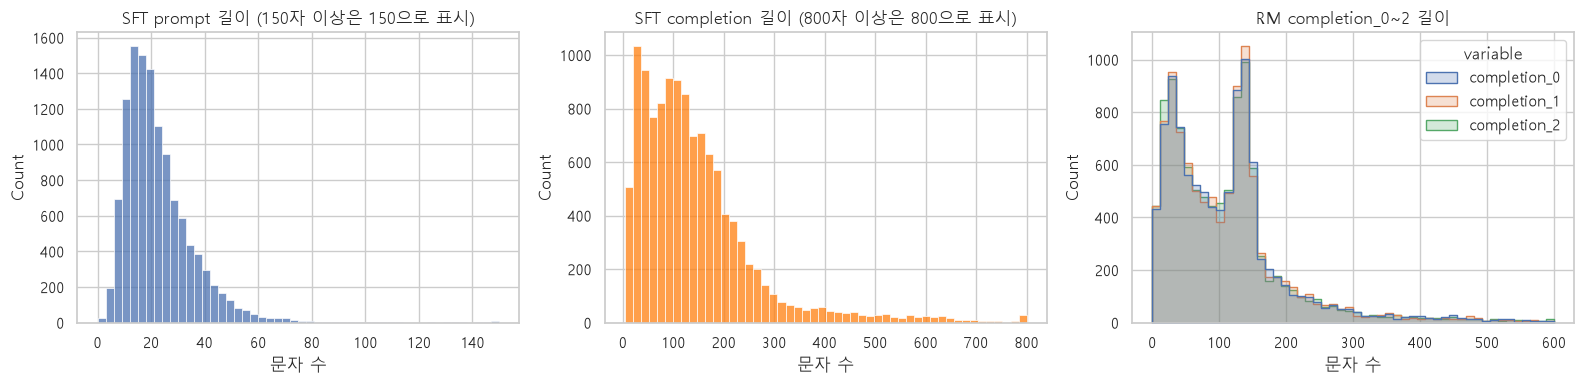

,count,mean,std,min,25%,50%,75%,max
prompt_len,12000.0,22.2,14.1,0.0,13.0,19.0,28.0,295.0
comp_len,12000.0,144.1,122.8,4.0,62.0,118.0,185.0,1553.0


In [5]:
def ko_ratio(t: str) -> float:
    # 공백을 뺀 글자 중 한글 비율 (영어 답변·깨진 답변 탐지용)
    t2 = re.sub(r"\s", "", t)
    return len(re.findall(r"[가-힣]", t2)) / max(1, len(t2))

df_sft["prompt_len"] = df_sft["prompt"].str.len()
df_sft["comp_len"] = df_sft["completion"].str.len()
rm_lens = pd.DataFrame({f"completion_{i}": df_rm[f"completion_{i}"].str.len() for i in range(3)})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_sft["prompt_len"].clip(upper=150), bins=50, ax=axes[0])
axes[0].set_title("SFT prompt 길이 (150자 이상은 150으로 표시)")
sns.histplot(df_sft["comp_len"].clip(upper=800), bins=50, ax=axes[1], color="tab:orange")
axes[1].set_title("SFT completion 길이 (800자 이상은 800으로 표시)")
sns.histplot(rm_lens.melt(value_name="len"), x="len", hue="variable", bins=50,
             element="step", ax=axes[2], binrange=(0, 600))
axes[2].set_title("RM completion_0~2 길이")
for ax in axes: ax.set_xlabel("문자 수")
plt.tight_layout(); cm.savefig(fig, "00_length_chars"); plt.show()

df_sft[["prompt_len", "comp_len"]].describe().T.round(1)

### 2-2. 길이 분포 (KoGPT2 토큰 수)

학습에 쓰는 `max_length`는 **토큰** 기준이다. 예제는 SFT `model_max_length=512`, RM `max_length=512`를 썼다. 실제 데이터가 몇 토큰인지 보고, 이 값이 적절한지 판단한다.

- SFT: `프롬프트 템플릿 + completion`
- RM: `prompt + completion` (RewardDataset 형식)

⏱ 약 1~2분 (토크나이저 첫 다운로드 포함)

토크나이저 클래스: TokenizersBackend | vocab 51,200
토큰: ['▁안녕', '하', '세', '요.', '▁반', '갑', '습니다.']
왕복 검사: '안녕하세요. 반갑습니다.' → ✅ 정상


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (920 > 512). Running this sequence through the model will result in indexing errors


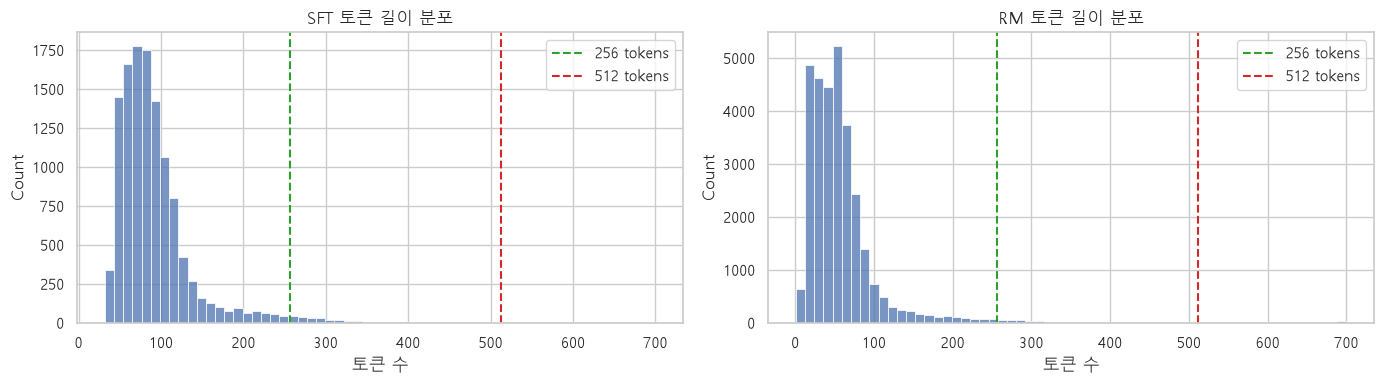

,data,median,p90,p95,p99,max,≤128 비율(%),≤256 비율(%),≤384 비율(%),≤512 비율(%)
0,SFT (템플릿+답변),81,137,188,285,920,87.8,98.2,99.9,100.0
1,RM (prompt+답변),49,97,142,277,1865,94.1,98.7,99.6,99.8


In [6]:
# [환경] transformers 5.x 에서는 AutoTokenizer 대신 전용 로더를 써야 KoGPT2 토큰화가 올바르다 (common.py 설명 참고)
tok = cm.load_kogpt2_tokenizer()

sft_texts = [cm.build_prompt(x["prompt"]) + x["completion"] for x in raw_sft]
rm_texts = [x["prompt"] + x[f"completion_{i}"] for x in raw_rm for i in range(3)]

sft_tok = np.array([len(ids) for ids in tok(sft_texts)["input_ids"]])
rm_tok = np.array([len(ids) for ids in tok(rm_texts)["input_ids"]])

def coverage_table(arr, name):
    row = {"data": name, "median": int(np.median(arr)), "p90": int(np.percentile(arr, 90)),
           "p95": int(np.percentile(arr, 95)), "p99": int(np.percentile(arr, 99)), "max": int(arr.max())}
    for L in [128, 256, 384, 512]:
        row[f"≤{L} 비율(%)"] = round((arr <= L).mean() * 100, 1)
    return row

tok_table = pd.DataFrame([coverage_table(sft_tok, "SFT (템플릿+답변)"), coverage_table(rm_tok, "RM (prompt+답변)")])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, arr, name in [(axes[0], sft_tok, "SFT"), (axes[1], rm_tok, "RM")]:
    sns.histplot(np.clip(arr, 0, 700), bins=60, ax=ax)
    for L, c in [(256, "tab:green"), (512, "tab:red")]:
        ax.axvline(L, color=c, ls="--", label=f"{L} tokens")
    ax.set_title(f"{name} 토큰 길이 분포"); ax.set_xlabel("토큰 수"); ax.legend()
plt.tight_layout(); cm.savefig(fig, "00_length_tokens"); plt.show()
tok_table

> **확인 포인트**: RM은 원본 코드에서 `padding="max_length"`로 **항상 512 토큰까지 패딩**한다. 대부분의 샘플이 256 토큰 안에 들어간다면, 512로 패딩하는 것은 계산 낭비이고 RM이 패딩 위치까지 평균을 내는 문제(01에서 설명)도 커진다. 이 표의 `≤256 비율`을 보고 02에서 RM `max_length`를 정한다.

### 2-3. 도메인 · 프롬프트 유형

프롬프트를 규칙 기반으로 3가지 유형으로 나눈다. 정확한 분류는 아니고 **데이터 구성의 대략적인 경향**을 보기 위한 것이다.

- **요청·지시**: "알려줘", "추천해줘", "방법" 등
- **질문**: 물음표·의문형 어미로 끝나거나 의문사(누구·언제·어디·몇 등)를 포함 (KorQuAD 스타일 사실 질문이 많음)
- **대화·감정 표현**: 그 외 짧은 서술 ("여친이랑 다툼", "술 먹고 싶어")

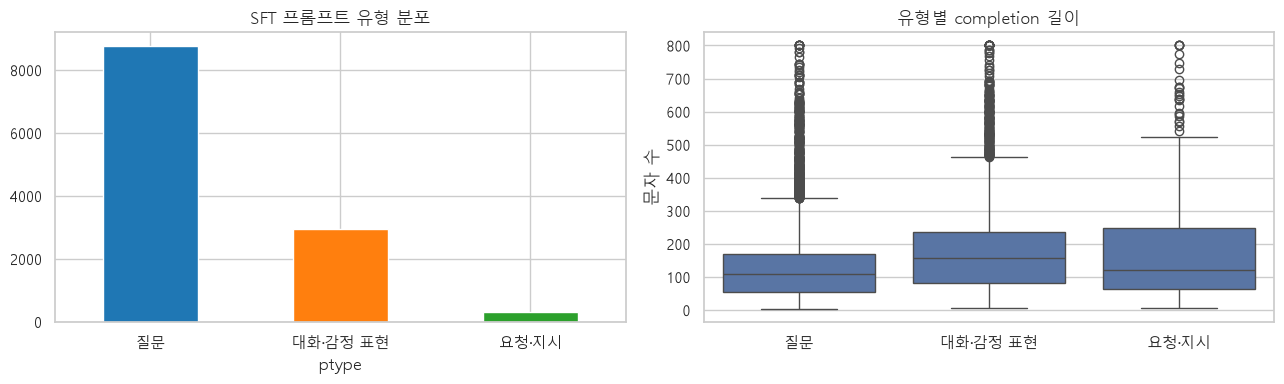

[질문] ['매리너 6호 CC&S가 실행할 수 있는 직접 커맨드 수는?', '화장실이나 흡연실도 따로 구비가 되어있나요?', '오세훈 시장이 리모델링한 후 무료 개방한 곳은?']
[대화·감정 표현] ['네 우선 서류 확인 도와드릴 텐데요 선생님 차량번호 확인 가능하십니까', '천문학 집대성을 아랍어로 발간한 책 이름은', '일을 거지같이해']
[요청·지시] ['현금 영수증 발급해주실래요?', '카를로스 움베르토 루이스 구티에레스의 소속팀 목록 알려줘', '윤회를 총애한 왕 이름 알려줘']


In [7]:
RE_REQUEST = re.compile(r"(알려|설명|추천|써|만들어|작성|정리|요약|번역|해)\s?(줘|주세요|줄래|주실|봐)|방법")
RE_QUESTION = re.compile(r"(\?|나요|까요|니|냐|는가|습니까|인가|은가|을까|야|어|지)\s*$")
RE_QWORD = re.compile(r"(누구|언제|어디|무엇|무슨|어떤|어느|몇|왜|어떻게|얼마)")  # 의문사

def prompt_type(p: str) -> str:
    if RE_REQUEST.search(p): return "요청·지시"
    if RE_QUESTION.search(p.strip()) or RE_QWORD.search(p): return "질문"
    return "대화·감정 표현"

df_sft["ptype"] = df_sft["prompt"].map(prompt_type)
ptype_cnt = df_sft["ptype"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ptype_cnt.plot.bar(ax=axes[0], color=["tab:blue", "tab:orange", "tab:green"], rot=0)
axes[0].set_title("SFT 프롬프트 유형 분포")
sns.boxplot(data=df_sft, x="ptype", y=df_sft["comp_len"].clip(upper=800), ax=axes[1])
axes[1].set_title("유형별 completion 길이"); axes[1].set_xlabel(""); axes[1].set_ylabel("문자 수")
plt.tight_layout(); cm.savefig(fig, "00_prompt_type"); plt.show()

for t in ptype_cnt.index:
    print(f"[{t}]", df_sft.loc[df_sft.ptype == t, "prompt"].sample(3, random_state=cm.SEED).tolist())

### 2-4. 문체

답변의 종결 어미로 문체를 나누고, ChatGPT가 생성한 데이터 특유의 **AI 면책 문구**("저는 인공지능 챗봇이며...") 비율을 확인한다. SFT 모델은 이 문체를 그대로 따라 배우게 된다.

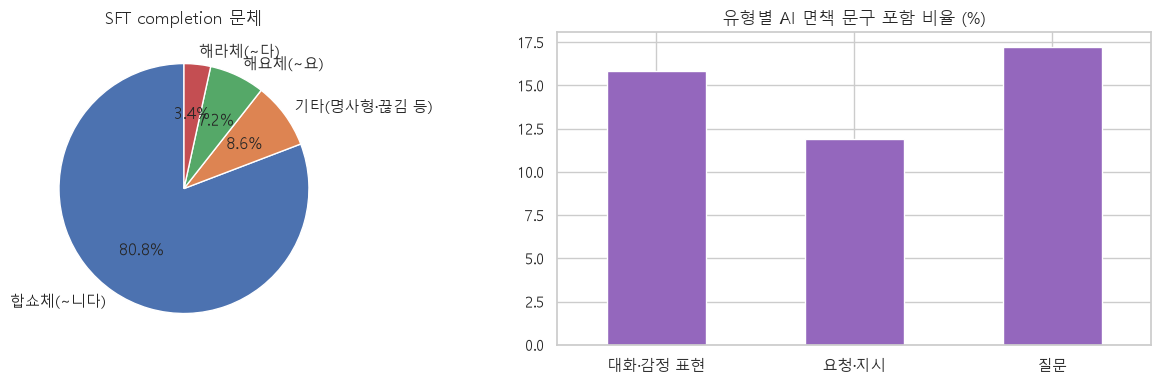

AI 면책 문구 포함: 2,008개 (16.7%)


In [8]:
def speech_style(c: str) -> str:
    c = c.strip().strip("'\"").rstrip(".!?~ ")
    if c.endswith("니다"): return "합쇼체(~니다)"
    if c.endswith("요"): return "해요체(~요)"
    if c.endswith("다"): return "해라체(~다)"
    return "기타(명사형·끊김 등)"

AI_DISCLAIMER = re.compile(r"^'?\s*(저는|나는)?\s*(인공지능|AI|에이아이)|언어\s?모델|As an AI|I am (a|an) (language model|AI)")

df_sft["style"] = df_sft["completion"].map(speech_style)
df_sft["ai_disclaimer"] = df_sft["completion"].map(lambda t: bool(AI_DISCLAIMER.search(t)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_sft["style"].value_counts().plot.pie(ax=axes[0], autopct="%.1f%%", startangle=90)
axes[0].set_ylabel(""); axes[0].set_title("SFT completion 문체")
df_sft.groupby("ptype")["ai_disclaimer"].mean().mul(100).plot.bar(ax=axes[1], rot=0, color="tab:purple")
axes[1].set_title("유형별 AI 면책 문구 포함 비율 (%)"); axes[1].set_xlabel("")
plt.tight_layout(); cm.savefig(fig, "00_style"); plt.show()
print(f"AI 면책 문구 포함: {df_sft['ai_disclaimer'].sum():,}개 ({df_sft['ai_disclaimer'].mean()*100:.1f}%)")

### 2-5. 문장 완성도 · 오염 패턴

원본 데이터는 API 응답을 가공하는 과정에서 생긴 흔적이 많이 남아 있다. 아래 패턴들을 탐지한다.

| 패턴 | 설명 |
|---|---|
| 앞뒤 따옴표 | completion 이 `'` 로 시작 (문자열 변환 흔적) |
| token 필드 누출 | 끝에 `", 'token': 154}` 처럼 원본 dict 의 일부가 붙어 있음 |
| dict 통째로 들어감 | completion 안에 `{'prompt': ..., 'completion': ...}` 가 그대로 있음 |
| prompt 오염 | prompt 필드에 `", 'completion': ...` 까지 섞여 들어감 |
| 문자 그대로의 `\n` | 줄바꿈이 실제 개행이 아니라 `\` + `n` 두 글자로 저장됨 |
| 비한국어 답변 | 한국어 질문에 영어로 답하거나 묻지 않은 번역을 함 |
| 문장 끊김 | 종결 부호·어미 없이 중간에 끝남 |
| 빈 prompt / 중복 prompt | 학습에 쓸 수 없거나 한쪽으로 치우치게 만듦 |

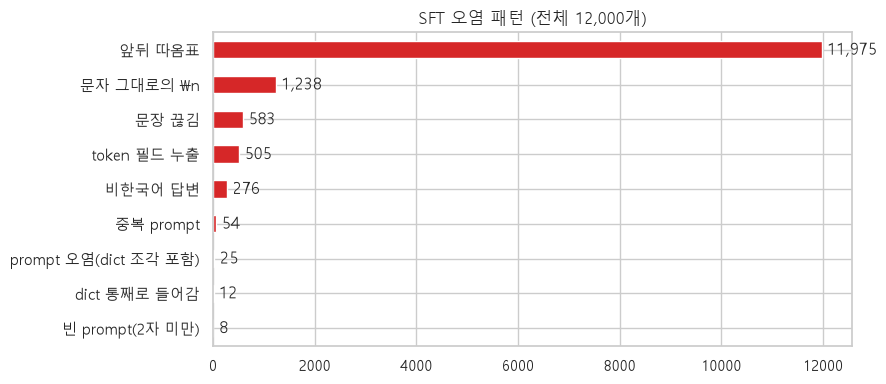

,개수,비율(%)
앞뒤 따옴표,11975,99.79
token 필드 누출,505,4.21
dict 통째로 들어감,12,0.10
문자 그대로의 \n,1238,10.32
비한국어 답변,276,2.30
문장 끊김,583,4.86
prompt 오염(dict 조각 포함),25,0.21
빈 prompt(2자 미만),8,0.07
중복 prompt,54,0.45


In [9]:
# [중요] 오염 패턴 정규식 — 아래 3. 정제 단계에서도 그대로 사용
RE_TOKEN_LEAK = re.compile(r"""["']?\s*,\s*['"]token['"]\s*:\s*\d+\s*\}?\s*$""")
RE_NESTED = re.compile(r"""^\{\s*['"]prompt['"]\s*:.*?['"]completion['"]\s*:\s*(["'])(.*)\1\s*(,\s*['"]token['"]\s*:\s*\d+\s*)?\}\s*$""", re.S)
RE_END = re.compile(r"""([.!?~)\]"”’』》」]|[다요죠까네음함임])\s*$""")  # 정상 종결로 보는 끝 글자
RE_PROMPT_KEY = re.compile(r"""["']\s*,\s*['"]completion['"]\s*:\s*""")  # prompt 안에 completion 키가 섞인 경우
TRANSLATE_KW = ("영어", "번역", "영문", "영작", "translate", "English")   # 영어 답변이 정당한 경우

C_ = df_sft["completion"]
P_ = df_sft["prompt"]
patterns = {
    "앞뒤 따옴표": C_.str.match(r"^\s*['\"]"),
    "token 필드 누출": C_.map(lambda t: bool(RE_TOKEN_LEAK.search(t))),
    "dict 통째로 들어감": C_.map(lambda t: bool(RE_NESTED.match(t.strip()))),
    "문자 그대로의 \\n": C_.str.contains("\\n", regex=False),
    "비한국어 답변": (C_.map(ko_ratio) < 0.1) & (C_.str.len() >= 30) & ~P_.map(lambda p: any(k in p for k in TRANSLATE_KW)),
    "문장 끊김": ~C_.map(lambda t: bool(RE_END.search(t.strip().strip("'\"")))),
    "prompt 오염(dict 조각 포함)": P_.map(lambda p: bool(RE_PROMPT_KEY.search(p))),
    "빈 prompt(2자 미만)": P_.str.strip().str.len() < 2,
    "중복 prompt": P_.str.strip().duplicated(),
}
pat_df = pd.DataFrame({"개수": {k: int(v.sum()) for k, v in patterns.items()}})
pat_df["비율(%)"] = (pat_df["개수"] / len(df_sft) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
pat_df["개수"].sort_values().plot.barh(ax=ax, color="tab:red")
ax.set_title(f"SFT 오염 패턴 (전체 {len(df_sft):,}개)")
for i, v in enumerate(pat_df["개수"].sort_values()): ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); cm.savefig(fig, "00_noise_patterns"); plt.show()
pat_df

In [10]:
# 패턴별 실제 예시 확인 (끝 80자)
for name in ["token 필드 누출", "비한국어 답변", "문장 끊김", "dict 통째로 들어감"]:
    print(f"── {name}")
    for _, r in df_sft[patterns[name]].head(2).iterrows():
        print(f"   Q: {r.prompt[:40]}\n   A: ...{r.completion[-80:]!r}")

── token 필드 누출
   Q: 프레스턴 브룩스는 의원직을 몇 년동안 역임했어
   A: ...' 의회의 의원이었는지 등의 정보가 필요합니다. 이에 대한 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.", \'token\': 154}'
   Q: 한명숙을 장관리더쉽평가에서 1위로 선정해준 신문은?
   A: ...'"한명숙 장관이 리더쉽 평가에서 1위로 선정된 신문은 \'조선일보\'입니다.", \'token\': 85}'
── 비한국어 답변
   Q: 목 마르다.
   A: ...'go sed." (Spanish) \\n\\n> "Ich bin durstig." (German) \\n\\n> "나는 목이 마르다." (Korean)'
   Q: 동거 8년 환승이별.
   A: ..."'8 years of living together, transfer separation."
── 문장 끊김
   Q: 프레스턴 브룩스는 의원직을 몇 년동안 역임했어
   A: ...' 의회의 의원이었는지 등의 정보가 필요합니다. 이에 대한 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.", \'token\': 154}'
   Q: 한명숙을 장관리더쉽평가에서 1위로 선정해준 신문은?
   A: ...'"한명숙 장관이 리더쉽 평가에서 1위로 선정된 신문은 \'조선일보\'입니다.", \'token\': 85}'
── dict 통째로 들어감
   Q: "푸시캣 돌시의 첫 싱글 'Don't Cha'는 빌보드 핫 100위 차트
   A: ...'", \'completion\': "\'Don\'t Cha\'는 2005년에 빌보드 핫 100위 차트에서 2위를 차지했습니다.", \'token\': 94}'
   Q: "'빅 대디' 는 무엇을 입고 있는가?", 'completion': "저
   A: ...' 무엇을 입고 있는지 파악할 수 없습니다. 해당 정보를 제공해주실 수 있으면 더욱 정확한 답변을 드릴 수 있습니다.", \'token\': 102}'


### 2-6. RM `ranking` 해석 검증

`ranking` 필드는 두 가지로 해석할 수 있다.

- **순서 해석**: `ranking = [2, 0, 1]` → **completion_2 가 1등**, completion_0 가 2등, completion_1 이 꼴등 (값이 completion 번호)
- **순위 해석**: `ranking = [2, 0, 1]` → completion_0 이 **2위**, completion_1 이 **0위(1등)**, completion_2 가 1위 (값이 순위)

예제에는 chosen/rejected 쌍을 만드는 코드가 두 가지 있다.

1. 첫 번째 방식: `if ranking[0] < ranking[1]` → **순위 해석**
2. 두 번째 방식: `n = ranking[0]` 을 1등 번호로 사용 → **순서 해석** (예제에서 최종적으로 쓰인 쪽)

두 해석이 다른 결과를 내는 것은 `[1,2,0]`, `[2,0,1]` 처럼 순환 형태인 경우다. 어느 쪽이 맞는지 **1등 답변과 꼴등 답변의 품질 차이**로 검증한다. 올바른 해석이라면 1등 답변이 더 길고 한국어 비율이 높아야 한다(꼴등에는 깨진 문장·영어가 많음).

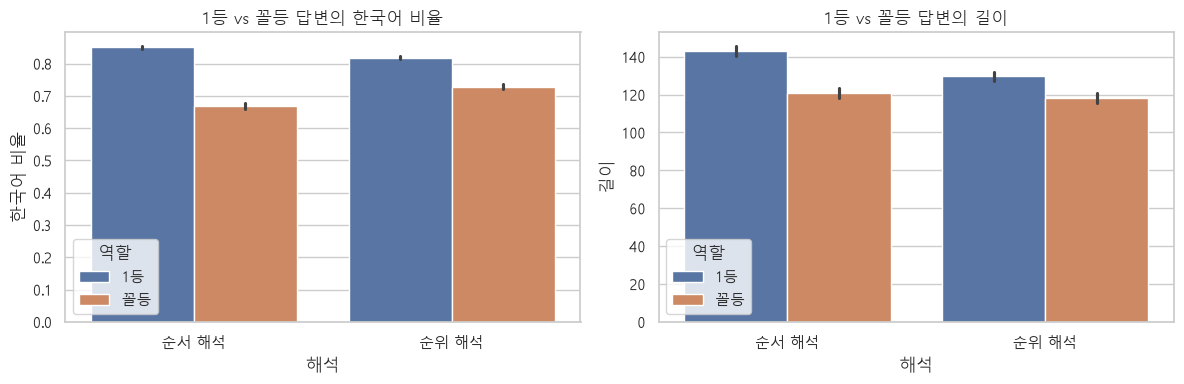

역할,1등,꼴등,차이(1등-꼴등)
해석,,,
순서 해석,0.850,0.668,0.182
순위 해석,0.818,0.728,0.091


두 해석이 달라지는 순환형 ranking: 3,450개 (33.8%)


In [11]:
def best_worst(ranking, mode):
    if mode == "순서 해석":   # 값 = completion 번호 (좋은 순)
        return ranking[0], ranking[-1]
    else:                     # 값 = 순위 (0이 1등)
        return ranking.index(0), ranking.index(2)

rows = []
for mode in ["순서 해석", "순위 해석"]:
    for x in raw_rm:
        b, w = best_worst(x["ranking"], mode)
        for role, idx in [("1등", b), ("꼴등", w)]:
            t = x[f"completion_{idx}"]
            rows.append({"해석": mode, "역할": role, "한국어 비율": ko_ratio(t), "길이": len(t)})
rk = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=rk, x="해석", y="한국어 비율", hue="역할", ax=axes[0])
sns.barplot(data=rk, x="해석", y="길이", hue="역할", ax=axes[1])
axes[0].set_title("1등 vs 꼴등 답변의 한국어 비율"); axes[1].set_title("1등 vs 꼴등 답변의 길이")
plt.tight_layout(); cm.savefig(fig, "00_rm_ranking_check"); plt.show()

gap = rk.groupby(["해석", "역할"])["한국어 비율"].mean().unstack()
gap["차이(1등-꼴등)"] = gap["1등"] - gap["꼴등"]
display(gap.round(3))

cyclic = sum(tuple(x["ranking"]) in [(1, 2, 0), (2, 0, 1)] for x in raw_rm)
print(f"두 해석이 달라지는 순환형 ranking: {cyclic:,}개 ({cyclic/len(raw_rm)*100:.1f}%)")

In [12]:
# 순환형 ranking 실제 예시: 어떤 답이 1등이어야 자연스러운지 직접 확인
ex = next(x for x in raw_rm if tuple(x["ranking"]) == (2, 0, 1))
print("Q:", ex["prompt"])
for i in range(3):
    print(f"  completion_{i}: {ex[f'completion_{i}'][:80]!r}")
print("ranking:", ex["ranking"])
b_order, b_rank = best_worst(ex["ranking"], "순서 해석")[0], best_worst(ex["ranking"], "순위 해석")[0]
print(f"  순서 해석 → 1등 completion_{b_order} / 순위 해석 → 1등 completion_{b_rank}")

Q: 개포주공아파트는 몇 단지로 이루어져 있나?
  completion_0: '개포주공아파트는 다섯 단지로 이루어져 있습니다.'
  completion_1: '이날 목송에서 구글상위노'
  completion_2: '개포주공아파트는 총 27개 단지로 이루어져 있습니다.'
ranking: [2, 0, 1]
  순서 해석 → 1등 completion_2 / 순위 해석 → 1등 completion_1


In [13]:
# SFT completion 이 RM 의 어느 답변과 같은지 확인 → SFT 정답이 곧 RM 1등 답변인지
sft_map = {x["prompt"]: x["completion"].strip().strip("'") for x in raw_sft}
match_rank = collections.Counter()
for x in raw_rm:
    ref = sft_map.get(x["prompt"])
    if ref is None: continue
    for pos, idx in enumerate(x["ranking"]):  # 순서 해석 기준 pos=0 이 1등
        if x[f"completion_{idx}"].strip()[:40] == ref[:40]:
            match_rank[f"{pos+1}등"] += 1
print("SFT 정답과 일치하는 RM 답변의 등수(순서 해석 기준):", dict(match_rank))

SFT 정답과 일치하는 RM 답변의 등수(순서 해석 기준): {'1등': 10176, '2등': 15}


> **결론**: 순서 해석에서 1등과 꼴등의 품질 차이가 더 크게 나타나고, SFT 정답이 순서 해석 기준 1등 답변과 일치한다. 따라서 **순서 해석이 맞고**, 예제의 첫 번째 쌍 생성 방식(순위 해석)은 순환형 ranking(약 1/3)에서 chosen/rejected가 뒤바뀐 쌍을 만든다. 예제에서 최종적으로 쓴 두 번째 방식은 올바르지만, 1등과의 비교 쌍 2개만 만들고 **2등 vs 3등 쌍은 버린다**.
>
> 또한 SFT 정답 = RM 1등 답변이므로, **RM 1등 답변을 SFT에 추가하는 증강은 사실상 중복**이 된다. 증강은 대화 데이터(5장)로 대신한다.

### 2-7. 데이터셋 간 prompt 중복

SFT / RM / PPO가 같은 prompt를 공유하는지 확인한다. 공유한다면, 평가셋으로 뗀 prompt가 RM·PPO 학습에 들어가지 않도록 **세 데이터셋 모두에서 제거**해야 공정한 평가가 된다.

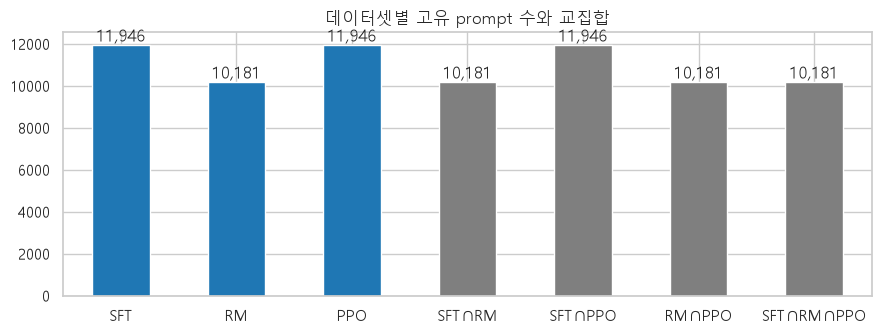

In [14]:
sp = {x["prompt"].strip() for x in raw_sft}
rp = {x["prompt"].strip() for x in raw_rm}
pp = {x["prompt"].strip() for x in raw_ppo}
ov = pd.Series({"SFT": len(sp), "RM": len(rp), "PPO": len(pp),
                "SFT∩RM": len(sp & rp), "SFT∩PPO": len(sp & pp), "RM∩PPO": len(rp & pp), "SFT∩RM∩PPO": len(sp & rp & pp)})
fig, ax = plt.subplots(figsize=(9, 3.5))
ov.plot.bar(ax=ax, rot=0, color=["tab:blue"] * 3 + ["tab:gray"] * 4)
for i, v in enumerate(ov): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("데이터셋별 고유 prompt 수와 교집합")
plt.tight_layout(); cm.savefig(fig, "00_prompt_overlap"); plt.show()

### EDA 요약 → 정제 방침

| 발견 | 처리 |
|---|---|
| 거의 모든 completion 앞에 `'` | 앞뒤 따옴표 제거 (수정) |
| `", 'token': N}` 누출, dict 통째 삽입, prompt 오염 | 정규식으로 원래 질문·답변만 추출 (수정) |
| prompt 오염 | prompt 필드에 `", 'completion': ...` 까지 섞여 들어감 |
| 문자 그대로의 `\n` | 실제 줄바꿈으로 변환 (수정) |
| 끊긴 문장 | 마지막 종결 지점까지 잘라서 살리고, 절반 이상 잘려야 하면 제거 |
| 묻지 않은 영어 답변·번역 | 제거 (번역 요청 prompt, 30자 미만 고유명사 답변은 유지) |
| 빈 prompt, 중복 prompt | 제거 |
| AI 면책 문구 | **유지** (데이터 문체의 일부. `[변경가능]` 옵션으로 제거 가능) |
| RM ranking | 순서 해석으로 3쌍 모두 생성 |
| 세 데이터셋이 prompt 공유 | 평가셋 prompt를 SFT/RM/PPO 모두에서 제거 |

짧은 답변("1953년입니다.")은 KorQuAD 스타일의 정상 답변이므로 **길이만으로 제거하지 않는다**.

## 3. SFT 데이터 정제

정제 함수는 **수정(fix)** 과 **제거(filter)** 를 분리했다. 수정은 텍스트를 고치고 태그를 남기며, 제거는 사유별로 개수를 센다.

In [15]:
# [변경가능] 정제 옵션
CLEAN_CFG = dict(
    newline_to="\n",          # 문자 그대로의 \n 을 무엇으로 바꿀지 ("\n" 실제 줄바꿈 / " " 공백)
    min_ko_ratio=0.1,         # 이 비율 미만이면 비한국어 답변으로 판단
    non_ko_min_len=30,        # 이 길이 미만의 비한국어 답변은 고유명사일 수 있어 유지 ("Hey Jude")
    trim_keep_ratio=0.5,      # 끊긴 문장을 자를 때 원문의 이 비율 이상 남아야 살림
    remove_ai_disclaimer=False,  # True 면 첫 문장의 AI 면책 문구 제거
)
RE_GPT3_NOTICE = re.compile(r"^이하는 GPT-3 모델의 자동 생성 내용으로[^\n.]*[.]?\s*")
RE_FIRST_DISCLAIMER = re.compile(r"^(저는|나는)\s*(인공지능|AI)[^.]*?(없|못|않)[^.]*\.\s*")

def fix_completion(c: str, cfg=CLEAN_CFG):
    # 텍스트 수정 → (수정된 텍스트, 적용된 수정 태그 목록). 샘플은 버리지 않고 고친다
    tags = []
    # ① dict 통째 삽입: {'prompt': "...", 'completion': "답변", 'token': 94} → 안쪽 "답변" 만 추출
    m = RE_NESTED.match(c.strip())
    if m:
        c = m.group(2); tags.append("dict 추출")
    # ② token 필드 누출: ...드릴 수 있습니다.", 'token': 154} → 끝의 ", 'token': 154} 제거
    c2 = RE_TOKEN_LEAK.sub("", c)
    if c2 != c: c = c2; tags.append("token 누출 제거")
    # ③ 문자 그대로의 \n: 줄바꿈이 '\' + 'n' 두 글자로 저장됨 → 실제 줄바꿈으로 변환
    #    [변경가능] 생성 시 eos 를 '\n'(id 375) 로 쓰면 첫 줄에서 답변이 끊기므로 02 디코딩 서치에서 함께 확인
    if "\\n" in c:
        c = c.replace("\\n", cfg["newline_to"]); tags.append("\\n 변환")
    # ④ 이스케이프된 작은따옴표 \' → '
    c = c.replace("\\'", "'")
    # ⑤ 앞뒤 따옴표: '저는 인공지능 챗봇이며... → 문자열 변환 때 붙은 따옴표 제거 (99.8% 해당)
    c2 = c.strip().strip("'\"").strip()
    if c2 != c: c = c2; tags.append("따옴표 제거")
    # ⑥ 생성 모델 안내문: "이하는 GPT-3 모델의 자동 생성 내용으로..." 첫 문장 제거
    c2 = RE_GPT3_NOTICE.sub("", c).strip()
    if c2 != c: c = c2; tags.append("GPT-3 안내문 제거")
    if cfg["remove_ai_disclaimer"]:
        c2 = RE_FIRST_DISCLAIMER.sub("", c).strip()
        if c2 != c and c2: c = c2; tags.append("AI 면책 제거")
    return c, tags

def fix_prompt(p: str):
    # prompt 에 completion 이 섞여 들어간 경우 → (질문만 남긴 prompt, 섞여 있던 completion or None)
    parts = RE_PROMPT_KEY.split(p, maxsplit=1)
    if len(parts) == 1:
        return p.strip(), None
    q, leaked = parts
    q = q.replace("\\'", "'").strip().strip("'\"").strip()
    leaked = RE_TOKEN_LEAK.sub("", leaked).replace("\\'", "'").strip().strip("'\"").strip()
    return q, leaked

def filter_pair(p: str, c: str, cfg=CLEAN_CFG):
    # 제거 판단 → (살릴 경우 최종 completion, 제거 사유 or None, 추가 수정 태그)
    if len(p) < 2: return None, "빈 prompt", []
    if len(c) < 2: return None, "빈 completion", []
    if ko_ratio(c) < cfg["min_ko_ratio"] and len(c) >= cfg["non_ko_min_len"] and not any(k in p for k in TRANSLATE_KW):
        return None, "비한국어 답변", []
    if not RE_END.search(c):
        idx = max(c.rfind(z) for z in [".", "!", "?", "다", "요"])
        if idx + 1 >= len(c) * cfg["trim_keep_ratio"]:
            return c[: idx + 1], None, ["끊긴 문장 자름"]
        return None, "끊긴 문장", []
    return c, None, []

def clean_sft(records, cfg=CLEAN_CFG, seen=None):
    # records: [{"prompt","completion"}] → 정제된 리스트, 수정 통계, 제거 통계
    seen = set() if seen is None else seen
    out, fix_cnt, drop_cnt = [], collections.Counter(), collections.Counter()
    for x in records:
        p, leaked = fix_prompt(x["prompt"])
        c, tags = fix_completion(leaked if leaked else x["completion"], cfg)
        if leaked: tags.append("prompt 오염 복구")
        c, reason, more = filter_pair(p, c, cfg)
        fix_cnt.update(tags + more)
        if reason: drop_cnt[reason] += 1; continue
        if p in seen: drop_cnt["중복 prompt"] += 1; continue
        seen.add(p)
        out.append({"prompt": p, "completion": c})
    return out, fix_cnt, drop_cnt

원본 12,000개 → 정제 후 11,640개 (제거 360개)


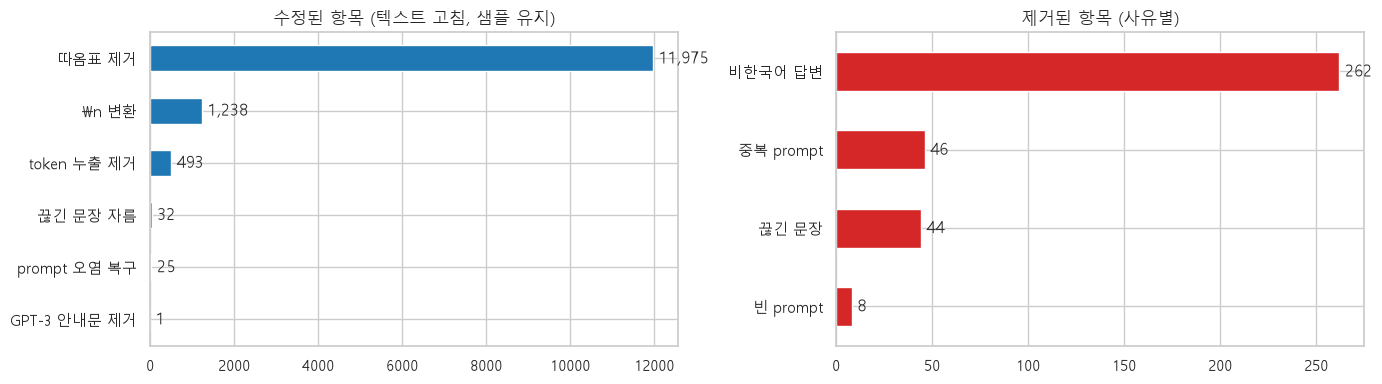

In [16]:
sft_clean, sft_fix, sft_drop = clean_sft(raw_sft)

print(f"원본 {len(raw_sft):,}개 → 정제 후 {len(sft_clean):,}개 (제거 {len(raw_sft)-len(sft_clean):,}개)")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(sft_fix).sort_values().plot.barh(ax=axes[0], color="tab:blue"); axes[0].set_title("수정된 항목 (텍스트 고침, 샘플 유지)")
pd.Series(sft_drop).sort_values().plot.barh(ax=axes[1], color="tab:red"); axes[1].set_title("제거된 항목 (사유별)")
for ax, s in [(axes[0], pd.Series(sft_fix).sort_values()), (axes[1], pd.Series(sft_drop).sort_values())]:
    for i, v in enumerate(s): ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout(); cm.savefig(fig, "00_cleaning_stats"); plt.show()

In [17]:
# 정제 전·후 비교 (token 누출이 있던 샘플)
idx = next(i for i, x in enumerate(raw_sft) if RE_TOKEN_LEAK.search(x["completion"]))
before = raw_sft[idx]["completion"]
after = next(x["completion"] for x in sft_clean if x["prompt"] == raw_sft[idx]["prompt"].strip())
print("정제 전 (끝부분):", repr(before[-90:]))
print("정제 후 (끝부분):", repr(after[-90:]))

정제 전 (끝부분): ' 역임했는지, 어떤 의회의 의원이었는지 등의 정보가 필요합니다. 이에 대한 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.", \'token\': 154}'
정제 후 (끝부분): '란 인물이 어느 나라의 의원을 역임했는지, 어떤 의회의 의원이었는지 등의 정보가 필요합니다. 이에 대한 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.'


### 3-1. 데이터 오염 내역과 처리 정리

원본 SFT 데이터 12,000개에서 발견된 오염과 처리 방법이다. 개수는 아래 코드 셀에서 실제로 다시 계산해 `results/cleaning_report.csv`로 저장한다. (표의 개수는 작성 시점 측정값)

| 오염 유형 | 개수 | 원인 추정 | 예시 (원본) | 처리 |
|---|---|---|---|---|
| 앞뒤 따옴표 | 11,975 | 답변을 문자열로 변환할 때 붙은 흔적 | `'저는 인공지능 챗봇이며, ...` | **수정**: 따옴표 제거 |
| 문자 그대로의 `\n` | 1,238 | 줄바꿈이 이스케이프된 채 저장됨 | `...다음과 같습니다.\n\n- 전두환: ...` | **수정**: 실제 줄바꿈으로 변환 |
| token 필드 누출 | 505 | API 응답 dict 를 문자열로 자를 때 끝부분이 딸려옴 | `...드릴 수 있습니다.", 'token': 154}` | **수정**: 끝의 dict 조각 제거 |
| prompt 오염 | 25 | prompt 칸에 completion 까지 들어감 | `"...했는가?", 'completion': "...", 'token': 94}` | **수정**: 질문과 답변을 분리해 복구 |
| dict 통째 삽입 | 12 | completion 칸에 원본 dict 전체가 들어감 | `{'prompt': "...", 'completion': "...", ...}` | **수정**: 안쪽 completion 만 추출 (prompt 오염 복구에서 함께 해결) |
| 문장 끊김 | 583 | 최대 토큰 제한으로 생성이 중간에 끊김 (token 누출 포함 수치) | `...쉽게 말해, 역세권` | **수정/제거**: 마지막 종결 지점까지 잘라 절반 이상 남으면 살리고, 아니면 제거 |
| 비한국어 답변 | 276 | 한국어 질문에 영어로 답하거나 묻지 않은 번역을 함 | Q `목 마르다.` → A `"I am thirsty." (English)...` | **제거** (번역 요청이거나 30자 미만 고유명사 답변은 유지) |
| 빈 prompt | 8 | 감탄사 한 글자 또는 빈 문자열 | 빈 문자열, `헉` | **제거** |
| 중복 prompt | 54 | 같은 질문이 여러 번 수집됨 | — | **제거** (첫 번째만 유지) |
| AI 면책 문구 | 약 2,000 | ChatGPT 답변 문체 | `저는 인공지능 챗봇이며, 직접적으로...` | **유지** (문체의 일부. `CLEAN_CFG["remove_ai_disclaimer"]` 로 제거 가능) |

**수정을 우선한 이유**: 과제 조건상 정제 후 데이터 크기가 줄지 않아야 한다. 오염의 대부분은 답변 내용 자체는 멀쩡하고 앞뒤에 흔적이 붙은 형태라서, 버리는 대신 고치면 데이터를 거의 잃지 않는다. 실제 제거는 약 360개(3%)에 그친다.

**베이스라인과의 관계**: 01 베이스라인은 예제와 동일하게 **정제하지 않은 원본**으로 학습한다. 그래서 베이스라인 모델은 답변 앞에 `'` 를 붙이거나 `'token':` 같은 문자열을 생성할 수 있고, 이것이 02에서 정제 효과를 비교하는 포인트가 된다.

In [18]:
# 실제 처리 결과(수정/제거)를 한 표로 저장
report = pd.DataFrame(
    [{"구분": "수정", "항목": k, "개수": v} for k, v in sft_fix.items()]
    + [{"구분": "제거", "항목": k, "개수": v} for k, v in sft_drop.items()]
).sort_values(["구분", "개수"], ascending=[True, False])
report.to_csv(cm.RESULT_DIR / "cleaning_report.csv", index=False, encoding="utf-8-sig")
print(f"원본 {len(raw_sft):,} → 정제 {len(sft_clean):,} (제거 {sum(sft_drop.values()):,}개, "
      f"{sum(sft_drop.values())/len(raw_sft)*100:.1f}%)")
report

원본 12,000 → 정제 11,640 (제거 360개, 3.0%)


,구분,항목,개수
0,수정,따옴표 제거,11975
1,수정,\n 변환,1238
2,수정,token 누출 제거,493
3,수정,끊긴 문장 자름,32
4,수정,prompt 오염 복구,25
5,수정,GPT-3 안내문 제거,1
6,제거,비한국어 답변,262
8,제거,중복 prompt,46
7,제거,끊긴 문장,44
9,제거,빈 prompt,8


## 4. Held-out 평가셋 분리

정제된 SFT 데이터의 **10%를 평가셋(test)** 으로 떼어 어떤 학습에도 쓰지 않는다. 정답(reference)이 깨끗해야 BLEU/ROUGE가 의미 있으므로, 평가셋은 **정제된 데이터**에서 뽑는다.

- `N_EVAL`: test 전체(약 1,160개)를 모델마다 생성하면 시간이 오래 걸려서, 고정된 부분집합으로 정량 평가한다. (KoGPT2 기준 200개 생성 약 2~3분, Trinity 4bit는 약 10~15분 예상)
- 평가셋 prompt는 **SFT / RM / PPO 학습 데이터 모두에서 제거**한다 (2-7에서 세 데이터셋이 prompt를 공유함을 확인).
- **베이스라인 학습 데이터**는 예제와 동일하게 **정제하지 않은 원본**을 쓰되, 평가셋 prompt만 뺀다. 그래야 "정제 효과"를 공정하게 비교할 수 있다.

In [19]:
TEST_RATIO = 0.10   # [변경가능] 평가셋 비율
N_EVAL = 200        # [변경가능] 정량 평가에 쓸 test 부분집합 크기 (시간과 정밀도의 트레이드오프)

rng = random.Random(cm.SEED)
shuffled = sft_clean[:]
rng.shuffle(shuffled)
n_test = int(len(shuffled) * TEST_RATIO)
sft_test = shuffled[:n_test]
sft_clean_train = shuffled[n_test:]
sft_eval = sft_test[:N_EVAL]                      # 모든 노트북이 같은 200개로 평가
test_prompts = {x["prompt"] for x in sft_test}

# 베이스라인: 원본(미정제) 그대로 + 평가셋 prompt 만 제거
sft_base_train = [x for x in raw_sft if x["prompt"].strip() not in test_prompts]

print(f"test          : {len(sft_test):,}개 (정량 평가용 부분집합 {len(sft_eval)}개)")
print(f"clean train   : {len(sft_clean_train):,}개")
print(f"baseline train: {len(sft_base_train):,}개 (원본 - 평가셋 prompt)")

test          : 1,164개 (정량 평가용 부분집합 200개)
clean train   : 10,476개
baseline train: 10,839개 (원본 - 평가셋 prompt)


## 5. 데이터 증강 (로컬 대화 데이터)

과제 조건: *정제 후 데이터셋 크기가 줄어들지 않도록 augmentation으로 유지 내지 증량*. 외부 데이터·API 없이 로컬 데이터만 사용한다.

### 증강 방법 결정 과정

| 단계 | 내용 |
|---|---|
| 초기 계획 | RM 데이터의 **1등 답변**을 (prompt, 답변) 쌍으로 SFT 에 추가 → 약 1만 개 증가 예상 |
| 검증 | 2-6 에서 SFT 정답과 RM 답변을 비교한 결과, **SFT 정답 = RM 1등 답변** (10,176개 일치) |
| 문제 | RM 1등 답변을 추가하면 같은 (질문, 답변) 쌍이 두 번 들어가는 **중복**이 된다. 새 정보는 없고 해당 샘플에 가중치만 두 배로 주는 셈 |
| 대안 검토 | RM 2·3등 답변은 품질이 낮아(깨진 문장·영어 비율 높음, 2-6 그래프) SFT 정답으로 쓰기 부적절 |
| 최종 결정 | 저장소에 함께 있지만 예제에서 쓰지 않은 **멀티턴 대화 데이터**(`kochatgpt_1_SFT_conversation.jsonl`)를 단일턴 쌍으로 변환해 추가 |

### 대화 데이터 변환 방법

`<사람>` → `<챗봇>` 으로 이어지는 턴을 한 쌍씩 뽑아 단일턴 SFT 데이터로 변환한다. 앞의 대화 맥락은 사용하지 않는다(단일턴 템플릿과 형식을 맞추기 위함).

대화 데이터에는 역할이 뒤섞인 턴(사람 발화에 "무엇을 도와드릴까요?")과 존재하지 않을 수 있는 URL이 포함된 답변이 있어 추가로 걸러낸다. 품질이 원본 SFT보다 낮을 수 있다는 점은 한계로 남긴다.

In [20]:
def parse_conversations(text: str):
    # <사람>: ... / <챗봇>: ... 텍스트 → (사람 발화, 바로 다음 챗봇 발화) 쌍 리스트
    pairs = []
    for blk in text.split("<<start conversation>>"):
        turns = re.findall(r"<(사람|챗봇)>:\s*(.*?)(?=\n<(?:사람|챗봇)>:|\Z)", blk, re.S)
        for (r1, u1), (r2, u2) in zip(turns, turns[1:]):
            if r1 == "사람" and r2 == "챗봇":
                pairs.append({"prompt": u1.strip(), "completion": u2.strip()})
    return pairs

conv_pairs = parse_conversations(raw_conv_text)
RE_ROLE_CONFUSION = re.compile(r"도와드릴까요|무엇을 도와|도움이 필요하신")
RE_URL = re.compile(r"https?://")

conv_pre = [x for x in conv_pairs if not RE_ROLE_CONFUSION.search(x["prompt"]) and not RE_URL.search(x["completion"])]
extra_drop = collections.Counter({"역할 혼동/URL": len(conv_pairs) - len(conv_pre)})

# 기존 학습셋·평가셋 prompt 와 겹치지 않도록 seen 에 미리 넣고 같은 정제 함수 적용
seen = {x["prompt"] for x in sft_clean_train} | test_prompts
conv_clean, conv_fix, conv_drop = clean_sft(conv_pre, seen=seen)
conv_drop.update(extra_drop)

print(f"대화 턴 쌍 {len(conv_pairs):,}개 → 증강 사용 {len(conv_clean):,}개")
print("제거 사유:", dict(conv_drop))
conv_clean[:2]

대화 턴 쌍 1,756개 → 증강 사용 1,597개
제거 사유: {'중복 prompt': 71, '역할 혼동/URL': 88}


[{'prompt': '괜찮습니다. 제가 알고 있는 주제에 대해 좀 더 알고 싶습니다.',
  'completion': '그러게요. 어떤 주제에 대해 알고 싶으신가요? 그리고 저는 어떤 정보를 찾아 드릴까요?'},
 {'prompt': '기계 학습에 대한 정보를 찾고 싶습니다.',
  'completion': '기계 학습에 대해 당신이 알고 싶은 것이 무엇인지 말씀해주시겠어요? 기계 학습은 인공 신경망을 사용하여 데이터를 분석하고 학습하는 방법을 말합니다. 보통 이러한 방법을 사용하여 비슷한 패턴을 발견하고 예측하거나 자동화된 분류를 수행합니다. 다양한 기계 학습 알고리즘이 있습니다. 제가 당신이 알고 싶은 것에 대해 참고 자료를 제공해 드릴까요?'}]

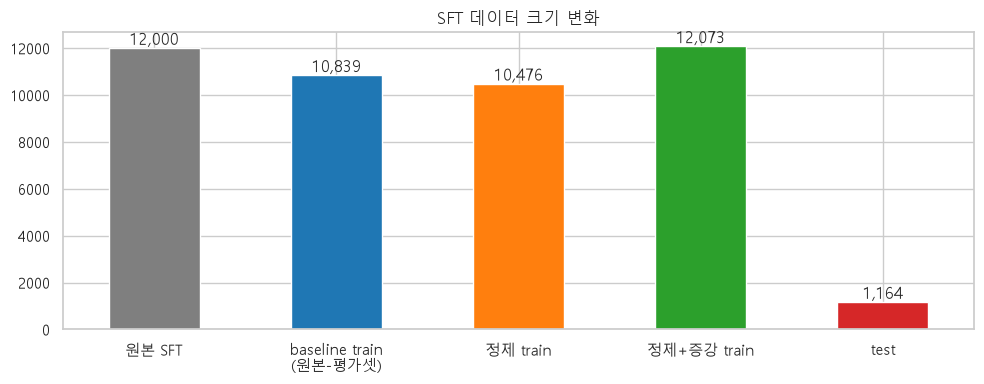

정제+증강 train(12,073) vs baseline train(10,839) → 유지/증가 ✅


In [21]:
USE_CONV_AUG = True   # [변경가능] 증강 사용 여부 (False 면 정제 데이터만으로 학습)

sft_final_train = sft_clean_train + (conv_clean if USE_CONV_AUG else [])
random.Random(cm.SEED).shuffle(sft_final_train)

sizes = pd.Series({
    "원본 SFT": len(raw_sft),
    "baseline train\n(원본-평가셋)": len(sft_base_train),
    "정제 train": len(sft_clean_train),
    "정제+증강 train": len(sft_final_train),
    "test": len(sft_test),
})
fig, ax = plt.subplots(figsize=(10, 4))
sizes.plot.bar(ax=ax, rot=0, color=["tab:gray", "tab:blue", "tab:orange", "tab:green", "tab:red"])
for i, v in enumerate(sizes): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("SFT 데이터 크기 변화")
plt.tight_layout(); cm.savefig(fig, "00_sft_sizes"); plt.show()
print(f"정제+증강 train({len(sft_final_train):,}) vs baseline train({len(sft_base_train):,}) → "
      f"{'유지/증가 ✅' if len(sft_final_train) >= len(sft_base_train) else '감소 ⚠️'}")

## 6. RM / PPO 데이터 준비

**RM 베이스라인** (예제 방식 재현): 순서 해석으로 1등 vs 2등, 1등 vs 3등 쌍 2개. 원본 텍스트를 그대로 쓴다.

**RM 정제**: 순서 해석으로 **3쌍 모두**(1등>2등, 1등>3등, 2등>3등) 생성하고, 텍스트는 SFT와 같은 `fix_completion`으로 고친다. chosen과 rejected가 같거나 비어 있는 쌍은 제거한다.

두 경우 모두 평가셋 prompt는 제외한다. 학습에 실제로 쓸 개수(예제: train 1,000 / eval 200)는 01·02 노트북에서 정한다.

In [22]:
def rm_pairs_baseline(records):
    # [예제 참고] 1등(ranking[0]) vs 나머지 → 쌍 2개. 원본 텍스트 그대로
    out = []
    for x in records:
        r = x["ranking"]
        for m in r[1:]:
            out.append({"prompt": x["prompt"], "chosen": x[f"completion_{r[0]}"], "rejected": x[f"completion_{m}"]})
    return out

def rm_pairs_clean(records):
    # [예제 수정] 순서 해석으로 모든 조합(3쌍) 생성 + 텍스트 정제 + 무의미한 쌍 제거
    out, dropped = [], 0
    for x in records:
        r = x["ranking"]
        texts = {i: fix_completion(x[f"completion_{i}"])[0] for i in range(3)}
        for a in range(3):
            for b in range(a + 1, 3):
                ch, rj = texts[r[a]], texts[r[b]]
                if not ch or not rj or ch == rj:
                    dropped += 1; continue
                out.append({"prompt": x["prompt"].strip(), "chosen": ch, "rejected": rj})
    return out, dropped

rm_src = [x for x in raw_rm if x["prompt"].strip() not in test_prompts]
rm_base = rm_pairs_baseline(rm_src)
rm_clean, rm_dropped = rm_pairs_clean(rm_src)
ppo_prompts = [x["prompt"] for x in raw_ppo if x["prompt"].strip() not in test_prompts and len(x["prompt"].strip()) >= 2]

print(f"RM 원본 {len(raw_rm):,}개 → 평가셋 제외 {len(rm_src):,}개")
print(f"  baseline 쌍: {len(rm_base):,}개 (x2)")
print(f"  clean 쌍   : {len(rm_clean):,}개 (x3, 제거 {rm_dropped}개)")
print(f"PPO prompt  : {len(raw_ppo):,}개 → {len(ppo_prompts):,}개")

RM 원본 10,220개 → 평가셋 제외 9,240개
  baseline 쌍: 18,480개 (x2)
  clean 쌍   : 27,656개 (x3, 제거 64개)
PPO prompt  : 12,000개 → 10,831개


## 7. 저장

이후 노트북은 모두 `data/` 의 파일만 읽는다. 원본 파일은 수정하지 않는다.

In [23]:
outputs = {
    "sft_base_train.json": sft_base_train,     # 01 베이스라인 SFT
    "sft_final_train.json": sft_final_train,   # 02·03 개선 SFT (정제+증강)
    "sft_test.json": sft_test,                 # 평가셋 전체
    "sft_eval.json": sft_eval,                 # 정량 평가용 고정 부분집합
    "rm_base_pairs.json": rm_base,             # 01 베이스라인 RM
    "rm_clean_pairs.json": rm_clean,           # 02 개선 RM
    "ppo_prompts.json": ppo_prompts,           # 01 PPO
}
for name, obj in outputs.items():
    cm.save_json(obj, cm.DATA_DIR / name)

summary = {
    "seed": cm.SEED, "test_ratio": TEST_RATIO, "n_eval": N_EVAL, "clean_cfg": CLEAN_CFG,
    "use_conv_aug": USE_CONV_AUG, "sizes": {k: len(v) for k, v in outputs.items()},
    "sft_fix": dict(sft_fix), "sft_drop": dict(sft_drop), "conv_drop": dict(conv_drop),
}
cm.save_json(summary, cm.RESULT_DIR / "data_summary.json")
pd.DataFrame({"file": list(outputs), "size": [len(v) for v in outputs.values()]})

,file,size
0,sft_base_train.json,10839
1,sft_final_train.json,12073
2,sft_test.json,1164
3,sft_eval.json,200
4,rm_base_pairs.json,18480
5,rm_clean_pairs.json,27656
6,ppo_prompts.json,10831


## 요약

- **정제**: 따옴표·token 누출·dict 삽입·`\n` 문자열 등 API 가공 흔적을 고치고, 비한국어·끊긴 문장·빈/중복 prompt를 제거했다.
- **증강**: 대화 데이터에서 단일턴 쌍을 추출해 정제 후 크기를 베이스라인 이상으로 유지했다.
- **RM**: ranking은 "순서 해석"이 맞다는 것을 품질 비교로 확인했고, 정제 RM 데이터는 3쌍을 모두 사용한다.
- **평가셋**: 정제 데이터의 10%를 분리해 모든 학습 데이터에서 제거했다.

다음: **01_baseline.ipynb** — 원본 데이터로 KoGPT2 Base / SFT / RM / PPO를 재현하고 비교한다.